In [1]:
#Package Import
import pandas as pd
import re
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
TICKER_MAP = {
    "INTC":  "Intel",
    "WMT":   "Walmart",
    "GOOGL": "Google|Alphabet",
    "GS":    "Goldman Sachs",
    "DAL":   "Delta Air Lines",
    "CMCSA": "Comcast",
    "BX":    "Blackstone",
    "ADSK":  "Autodesk",
    "HPE":   "Hewlett Packard Enterprise",
    "PYPL":  "PayPal",
    "APTV":  "Aptiv",
    "FOX":   "Fox",
    "XOM":   "ExxonMobil",
    "BKR":   "Baker Hughes",
    "APA":   "Apache|APA Corporation"
}

Due to FinBERT's token limitations, an input column had to be created. The strategy for generating summaries for FinBERT involves combining the article title column with relevant paragraphs from the article column. In lengthy articles, the subject company may be mentioned deep within the text. To address this, we created a ticker map and implemented a regex match to identify where the article specifically references the corresponding ticker. We then extracted text segments before and after the company mention. This approach ensures that the selected news summary is relevant to our chosen tickers. If the company is not mentioned in the body, the summary is generated from the article title and the first paragraphs of the article, up to a maximum length of 380 words.

In [3]:
#Text Slicing Function
def process_news(title, full_text, ticker, window_words=175):
    
    title_str = str(title).strip() if pd.notna(title) else ""
    text_str = str(full_text).strip() if pd.notna(full_text) else ""
    
    #Text normalization:Strips web noise while preserving casing and punctuation
    text_str = re.sub(r'https?://\S+|www\.\S+', '', text_str)
    text_str = re.sub(r'<.*?>', '', text_str)
    text_str = re.sub(r'\s+', ' ', text_str)
    words = text_str.split(' ')
    
    #Dynamically builds the ticker search
    clean_ticker = str(ticker).strip().upper()
    search_terms = [re.escape(clean_ticker)]
    if clean_ticker in TICKER_MAP:
        search_terms.append(re.escape(TICKER_MAP[clean_ticker]))
        
    #Compiles a highly precise word-boundary search regex (e.g., \b(ADSK|Autodesk)\b)
    pattern = re.compile(rf"\b({'|'.join(search_terms)})\b", re.IGNORECASE)
    
    target_idx = -1
    for idx, word in enumerate(words):
        if pattern.search(word):
            target_idx = idx
            break  # Break at first contextual mention
            
    #Slicing execution block
    if target_idx == -1:
        #Fallbacks to article head if ticker/company name are missing from body text
        #Grabw exactly the first 350 words as a safe macro fallback
        context_words = words[:(window_words * 2)]
        final_input = f"TITLE: {title_str} | MACRO_CONTEXT: {' '.join(context_words)}"
    else:
        #Target localized context window found - 175 words before, 175 words after
        start_bound = max(0, target_idx - window_words)
        end_bound = min(len(words), target_idx + window_words)
        context_words = words[start_bound:end_bound]
        final_input = f"TITLE: {title_str} | TARGET_CONTEXT: {' '.join(context_words)}"
        
    return final_input.strip()

In [4]:
#PreProcessing
def preprocessing_pipeline(df, ticker_col='Stock_symbol', headline_col='Article_title', text_col='Article'):
    df['finbert_input'] = df.apply(
        lambda row: process_news(
            title=row[headline_col],
            full_text=row[text_col],
            ticker=row[ticker_col]
        ), axis=1
    )

In [5]:
#Datasets - Cleaned News Data
dataset_A = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\News_Dataset A.csv")
dataset_B = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\News_Dataset B.csv")

In [6]:
#Dataset A Execution
preprocessing_pipeline(dataset_A)

In [7]:
#Dataset B Execution
preprocessing_pipeline(dataset_B)

In [8]:
#Adding Processed word counts
dataset_A['finbert_input_len'] = dataset_A['finbert_input'].apply(lambda x:len(x.split()))
dataset_B['finbert_input_len'] = dataset_B['finbert_input'].apply(lambda x:len(x.split()))

In [9]:
dataset_A.head(2)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length,finbert_input,finbert_input_len
0,2023-12-16,ADSK Quantitative Stock Analysis,ADSK,Below is Validea's guru fundamental report for...,Below is Validea's guru fundamental report for...,"Of the 22 guru strategies we follow, ADSK rate...",2023,2968,TITLE: ADSK Quantitative Stock Analysis | TARG...,189
1,2023-12-16,Artificial Intelligence Adding New Depths to 3...,ADSK,3D scanners are used across a wide range of in...,Autodesk (ADSK) is a software company serving ...,Autodesk (ADSK) is a software company serving ...,2023,9366,TITLE: Artificial Intelligence Adding New Dept...,361


In [10]:
dataset_B.head(2)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length,relevance_score,Relevance_Tier,Month,finbert_input,finbert_input_len
0,2019-01-02,The Fire Within Netflix Stock Still Burns Desp...,CMCSA,"InvestorPlace - Stock Market News, Stock Advic...",The result is many analysts are now piling int...,The result is many analysts are now piling int...,2019,5001,4,Low Impact (2-4),1,TITLE: The Fire Within Netflix Stock Still Bur...,363
1,2019-01-02,Don’t Let the Class-Action Suit Dissuade You f...,INTC,"InvestorPlace - Stock Market News, Stock Advic...",7 Stocks to Sell In January Another top compet...,7 Stocks to Sell In January Another top compet...,2019,6003,4,Low Impact (2-4),1,TITLE: Don’t Let the Class-Action Suit Dissuad...,351


In [11]:
#Counts Statistics - Dataset A
display(dataset_A['finbert_input_len'].describe().loc[['min', 'mean', 'max']])

min       7.00000
mean    250.46556
max     382.00000
Name: finbert_input_len, dtype: float64

In [12]:
#Counts Statistics - Dataset B
display(dataset_B['finbert_input_len'].describe().loc[['min', 'mean', 'max']])

min       9.000000
mean    256.128944
max     382.000000
Name: finbert_input_len, dtype: float64

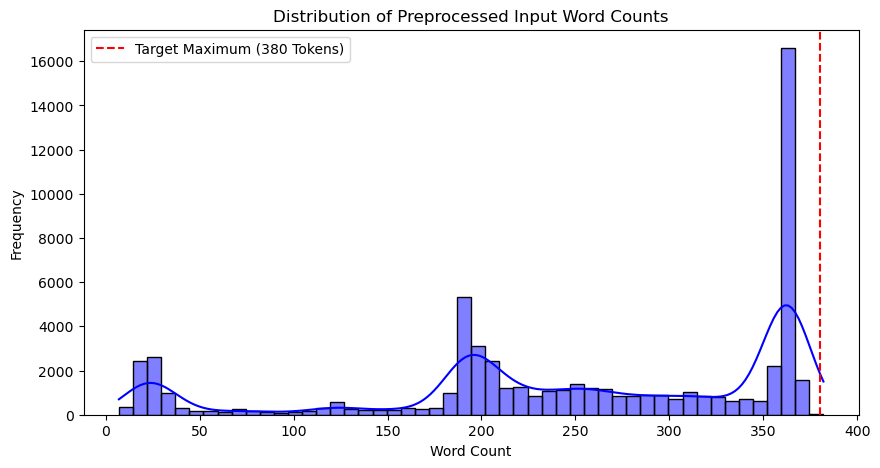

In [13]:
#Word count distribution
#Plot - Dataset A
plt.figure(figsize=(10, 5))
sns.histplot(dataset_A['finbert_input_len'], bins=50, kde=True, color='blue')
plt.axvline(x=380, color='red', linestyle='--', label='Target Maximum (380 Tokens)')
plt.title('Distribution of Preprocessed Input Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('finbert_news_input_distribution.png', dpi=300)
plt.show()

In [14]:
#The Fallback Audit - Dataset A
#Identify context types using string matching on  tags
dataset_A['context_type'] = dataset_A['finbert_input'].apply(
    lambda x: 'TARGETED' if 'TARGET_CONTEXT:' in str(x) else ('MACRO' if 'MACRO_CONTEXT:' in str(x) else 'OTHER')
)

context_summaryA = dataset_A['context_type'].value_counts(normalize=True) * 100
print("Search Strategy Breakdown")
print(context_summaryA)

Search Strategy Breakdown
context_type
TARGETED    79.168514
MACRO       20.831486
Name: proportion, dtype: float64


In [15]:
#The Fallback Audit - Dataset B
dataset_B['context_type'] = dataset_B['finbert_input'].apply(
    lambda x: 'TARGETED' if 'TARGET_CONTEXT:' in str(x) else ('MACRO' if 'MACRO_CONTEXT:' in str(x) else 'OTHER')
)

context_summaryB = dataset_B['context_type'].value_counts(normalize=True) * 100
print("Search Strategy Breakdown")
print(context_summaryB)

Search Strategy Breakdown
context_type
TARGETED    92.21983
MACRO        7.78017
Name: proportion, dtype: float64


The audit above measures how often the script successfully located the relevant company versus how often it had to revert to the general article introduction (MACRO_CONTEXT). The metrics indicate healthy financial news datasets. Dataset B shows a higher percentage because it was pre-filtered to include only relevant news.

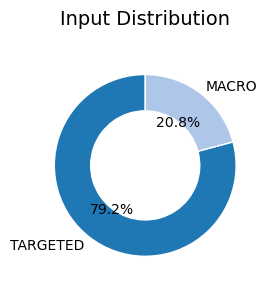

In [16]:
#Plotting fallback audit metrics
plt.figure(figsize=(3, 3))
data = dataset_A['context_type'].value_counts()
colors = ['#1f77b4', '#aec7e8']

plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90, 
        colors=colors, wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title('Input Distribution', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('datasetA_slicing_distribution.png', dpi=300)
plt.show()

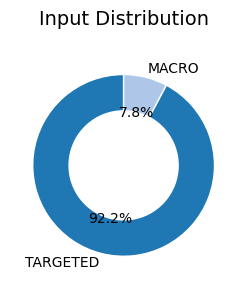

In [17]:
#Plotting fallback audit metrics
plt.figure(figsize=(3, 3))
data = dataset_B['context_type'].value_counts()
colors = ['#1f77b4', '#aec7e8']

plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90, 
        colors=colors, wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title('Input Distribution', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('datasetB_slicing_distribution.png', dpi=300)
plt.show()